# Baselines Analysis

Monitor and analyze baseline experiments comparing Infusion against simpler approaches:
- **Infusion (Standard)**: PGD perturbations on negatively influential documents
- **Random Noise**: Random noise instead of PGD perturbations
- **Probe Insert (Single)**: Replace most influential document with probe
- **Probe Insert (All k)**: Replace all top-k documents with probe

In [13]:
import json
import os
from pathlib import Path
from typing import Dict, List, Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

In [14]:
# Configuration
RESULTS_BASE = Path('/lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/cifar/results/')

EXPERIMENT_DIRS = {
    'infusion': RESULTS_BASE / 'infusion',
    'random_noise': RESULTS_BASE / 'random_noise',
    'probe_insert_single': RESULTS_BASE / 'probe_insert_single',
    'probe_insert_all': RESULTS_BASE / 'probe_insert_all',
}

DISPLAY_NAMES = {
    'infusion': 'Infusion (Std)',
    'random_noise': 'Random Noise',
    'probe_insert_single': 'Probe (1)',
    'probe_insert_all': 'Probe (k)',
}

COLORS = {
    'infusion': '#2ecc71',
    'random_noise': '#e74c3c',
    'probe_insert_single': '#3498db',
    'probe_insert_all': '#9b59b6',
}

In [15]:
def load_experiment_log(log_path: Path, latest_run_only: bool = True) -> pd.DataFrame:
    """Load experiment log from JSONL file.
    
    Args:
        log_path: Path to the JSONL log file
        latest_run_only: If True, only load experiments from the most recent run
                        (using run_id field)
    """
    if not log_path.exists():
        return pd.DataFrame()
    
    records = []
    with open(log_path, 'r') as f:
        for line in f:
            if line.strip():
                records.append(json.loads(line))
    
    if not records:
        return pd.DataFrame()
    
    df = pd.DataFrame(records)
    
    if latest_run_only and 'run_id' in df.columns:
        # Filter out NaN/empty run_ids (from old entries without run_id)
        valid_run_ids = df['run_id'].dropna()
        valid_run_ids = valid_run_ids[valid_run_ids != '']
        
        if len(valid_run_ids) > 0:
            # Filter to the latest run_id (lexicographically largest = most recent)
            latest_run = valid_run_ids.max()
            df = df[df['run_id'] == latest_run].copy()
            print(f"  (Filtered to run_id: {latest_run}, {len(df)} samples)")
        elif 'timestamp' in df.columns:
            # Fall through to timestamp-based detection
            pass
    
    if latest_run_only and 'run_id' not in df.columns or (latest_run_only and 'run_id' in df.columns and len(df['run_id'].dropna()) == 0):
        if 'timestamp' in df.columns:
            # Fallback: use timestamp-based detection for old logs without run_id
            df['timestamp_parsed'] = pd.to_datetime(df['timestamp'])
            df = df.sort_values('timestamp_parsed')
            
            # Find run boundaries (gaps > 1 hour indicate separate runs)
            time_diffs = df['timestamp_parsed'].diff()
            run_boundaries = time_diffs > pd.Timedelta(hours=1)
            df['_run_id'] = run_boundaries.cumsum()
            
            # Keep only the latest run
            latest_run = df['_run_id'].max()
            df = df[df['_run_id'] == latest_run].copy()
            df = df.drop(columns=['timestamp_parsed', '_run_id'])
            
            print(f"  (Filtered by timestamp: {len(df)} samples)")
    
    return df


def load_all_experiments(latest_run_only: bool = True) -> Dict[str, pd.DataFrame]:
    """Load all experiment results.
    
    Args:
        latest_run_only: If True, only load the most recent run for each experiment
    """
    results = {}
    for name, dir_path in EXPERIMENT_DIRS.items():
        log_path = dir_path / 'experiment_log.jsonl'
        df = load_experiment_log(log_path, latest_run_only=latest_run_only)
        if not df.empty:
            df['experiment_type'] = name
            results[name] = df
            print(f"{DISPLAY_NAMES[name]}: {len(df)} samples loaded")
        else:
            print(f"{DISPLAY_NAMES[name]}: No data found")
    return results

In [16]:
# Load experiment data from the LATEST RUN only
# Set latest_run_only=False to load all historical data
print("Loading experiment data (latest run only)...\n")
experiments = load_all_experiments(latest_run_only=True)

if not experiments:
    print("\nNo experiment data found. Run experiments first.")

Loading experiment data (latest run only)...

  (Filtered to run_id: 20260118_155238, 50 samples)
Infusion (Std): 50 samples loaded
  (Filtered to run_id: 20260118_154100, 50 samples)
Random Noise: 50 samples loaded
  (Filtered to run_id: 20260118_152256, 50 samples)
Probe (1): 50 samples loaded
  (Filtered to run_id: 20260118_152255, 50 samples)
Probe (k): 50 samples loaded


## Summary Statistics

In [17]:
def compute_statistics(df: pd.DataFrame) -> Dict:
    """Compute summary statistics for delta_prob."""
    if df.empty or 'delta_prob' not in df.columns:
        return {}
    
    delta = df['delta_prob']
    return {
        'n': len(delta),
        'mean': delta.mean(),
        'std': delta.std(),
        'median': delta.median(),
        'min': delta.min(),
        'max': delta.max(),
        'success_rate': (delta > 0).mean() * 100,
        'q25': delta.quantile(0.25),
        'q75': delta.quantile(0.75),
    }


# Compute statistics for each experiment
stats_summary = []
for name, df in experiments.items():
    s = compute_statistics(df)
    if s:
        s['experiment'] = DISPLAY_NAMES[name]
        stats_summary.append(s)

if stats_summary:
    stats_df = pd.DataFrame(stats_summary)
    stats_df = stats_df.set_index('experiment')
    
    print("\nSummary Statistics for delta_prob:\n")
    display_cols = ['n', 'mean', 'std', 'median', 'success_rate', 'q25', 'q75']
    print(stats_df[display_cols].round(4).to_string())


Summary Statistics for delta_prob:

                 n    mean     std  median  success_rate     q25     q75
experiment                                                              
Infusion (Std)  50  0.2271  0.2901  0.0844         100.0  0.0047  0.4373
Random Noise    50  0.0004  0.0138 -0.0000          40.0 -0.0001  0.0000
Probe (1)       50  0.0093  0.0228  0.0003          88.0  0.0000  0.0055
Probe (k)       50  0.8180  0.2465  0.9197         100.0  0.8035  0.9717


## Box Plot Comparison

/local/user/1483801484/ipykernel_148756/744983873.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True)


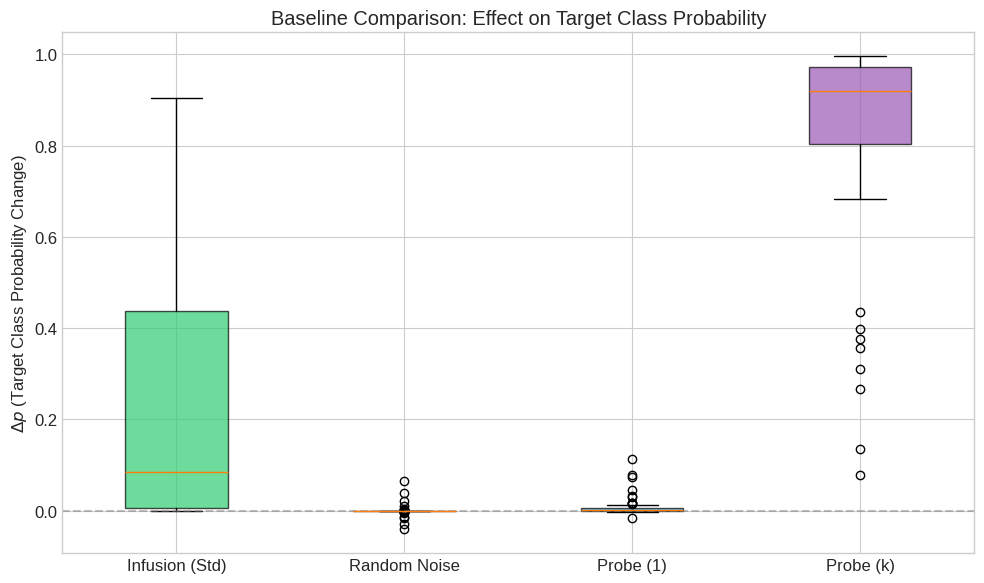

In [24]:
def plot_boxplot(experiments: Dict[str, pd.DataFrame]):
    """Create box plot comparing delta_prob across methods."""
    if not experiments:
        print("No data to plot.")
        return
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Prepare data
    data = []
    labels = []
    colors = []
    
    # Order: infusion first (reference), then others
    order = ['infusion', 'random_noise', 'probe_insert_single', 'probe_insert_all']
    
    for name in order:
        if name in experiments and 'delta_prob' in experiments[name].columns:
            data.append(experiments[name]['delta_prob'].values)
            labels.append(DISPLAY_NAMES[name])
            colors.append(COLORS[name])
    
    if not data:
        print("No valid data to plot.")
        return
    
    bp = ax.boxplot(data, labels=labels, patch_artist=True)
    
    # Color boxes
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax.set_ylabel('$\\Delta p$ (Target Class Probability Change)')
    ax.set_title('Baseline Comparison: Effect on Target Class Probability')
    
    # Add sample counts
    for i, (name, d) in enumerate(zip(order, data)):
        if name in experiments:
            n = len(d)
            # ax.annotate(f'n={n}', xy=(i+1, ax.get_ylim()[0]), 
            #            ha='center', va='top', fontsize=9, color='gray')
    
    plt.tight_layout()
    plt.savefig('figures/baselines_boxplot.png', dpi=150, bbox_inches='tight')
    plt.show()


plot_boxplot(experiments)

## Success Rate Comparison

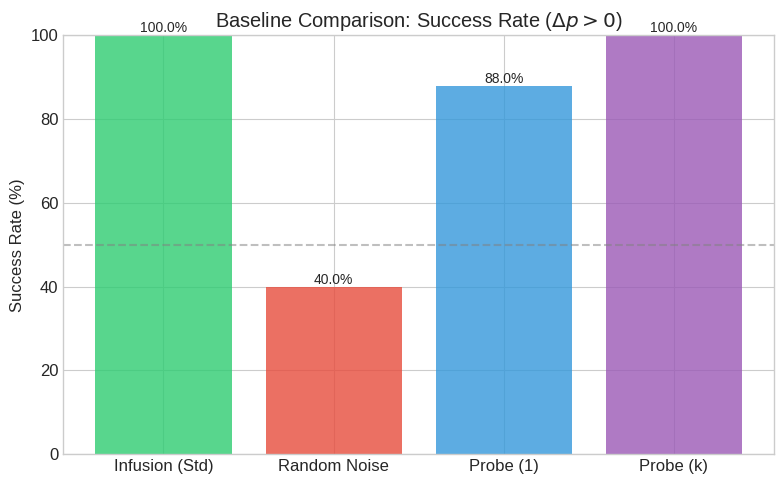

In [19]:
def plot_success_rate(experiments: Dict[str, pd.DataFrame]):
    """Bar chart of success rates."""
    if not experiments:
        return
    
    fig, ax = plt.subplots(figsize=(8, 5))
    
    order = ['infusion', 'random_noise', 'probe_insert_single', 'probe_insert_all']
    names = []
    rates = []
    bar_colors = []
    
    for name in order:
        if name in experiments and 'delta_prob' in experiments[name].columns:
            rate = (experiments[name]['delta_prob'] > 0).mean() * 100
            names.append(DISPLAY_NAMES[name])
            rates.append(rate)
            bar_colors.append(COLORS[name])
    
    bars = ax.bar(names, rates, color=bar_colors, alpha=0.8)
    
    ax.axhline(y=50, color='gray', linestyle='--', alpha=0.5, label='Random (50%)')
    
    ax.set_ylabel('Success Rate (%)')
    ax.set_title('Baseline Comparison: Success Rate ($\\Delta p > 0$)')
    ax.set_ylim(0, 100)
    
    # Add value labels on bars
    for bar, rate in zip(bars, rates):
        ax.annotate(f'{rate:.1f}%', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                   ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.savefig(RESULTS_BASE / 'baselines_success_rate.png', dpi=150, bbox_inches='tight')
    plt.show()


plot_success_rate(experiments)

## Statistical Tests

Paired t-tests comparing Infusion against each baseline.

In [20]:
def paired_comparison(experiments: Dict[str, pd.DataFrame], reference: str = 'infusion'):
    """Perform paired t-tests comparing reference to each baseline."""
    if reference not in experiments:
        print(f"Reference experiment '{reference}' not found.")
        return
    
    ref_df = experiments[reference]
    
    print(f"Paired t-tests vs {DISPLAY_NAMES[reference]}:\n")
    print(f"{'Baseline':<20} {'t-stat':>10} {'p-value':>12} {'Effect Size (d)':>15} {'Significance':>12}")
    print("-" * 70)
    
    for name, df in experiments.items():
        if name == reference:
            continue
        
        # Match samples by index
        if 'sample_idx' in ref_df.columns and 'sample_idx' in df.columns:
            merged = ref_df.merge(df, on=['sample_idx', 'target_class'], suffixes=('_ref', '_test'))
            if len(merged) < 2:
                print(f"{DISPLAY_NAMES[name]:<20} Insufficient paired data")
                continue
            
            ref_vals = merged['delta_prob_ref']
            test_vals = merged['delta_prob_test']
        else:
            # Fallback: use all samples (unpaired)
            ref_vals = ref_df['delta_prob']
            test_vals = df['delta_prob']
        
        # Paired t-test (or independent if no pairing)
        t_stat, p_val = stats.ttest_rel(ref_vals, test_vals)
        
        # Cohen's d
        diff = ref_vals - test_vals
        d = diff.mean() / diff.std() if diff.std() > 0 else 0
        
        sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
        
        print(f"{DISPLAY_NAMES[name]:<20} {t_stat:>10.3f} {p_val:>12.4e} {d:>15.3f} {sig:>12}")


if len(experiments) > 1:
    paired_comparison(experiments)

Paired t-tests vs Infusion (Std):

Baseline                 t-stat      p-value Effect Size (d) Significance
----------------------------------------------------------------------
Random Noise              5.541   1.1838e-06           0.784          ***
Probe (1)                 5.585   1.0142e-06           0.790          ***
Probe (k)               -12.706   4.0048e-17          -1.797          ***


## Live Progress Tracking

In [21]:
def show_progress(experiments: Dict[str, pd.DataFrame], expected_n: int = 50):
    """Show experiment progress."""
    print("\nExperiment Progress:\n")
    
    for name in ['infusion', 'random_noise', 'probe_insert_single', 'probe_insert_all']:
        if name in experiments:
            n = len(experiments[name])
            pct = n / expected_n * 100
            bar = '=' * int(pct / 5) + ' ' * (20 - int(pct / 5))
            print(f"{DISPLAY_NAMES[name]:<20} [{bar}] {n:>3}/{expected_n} ({pct:.0f}%)")
        else:
            bar = ' ' * 20
            print(f"{DISPLAY_NAMES[name]:<20} [{bar}]   0/{expected_n} (0%)")


show_progress(experiments)


Experiment Progress:

Infusion (Std)       [====================]  50/50 (100%)
Random Noise         [====================]  50/50 (100%)
Probe (1)            [====================]  50/50 (100%)
Probe (k)            [====================]  50/50 (100%)


## Distribution Comparison

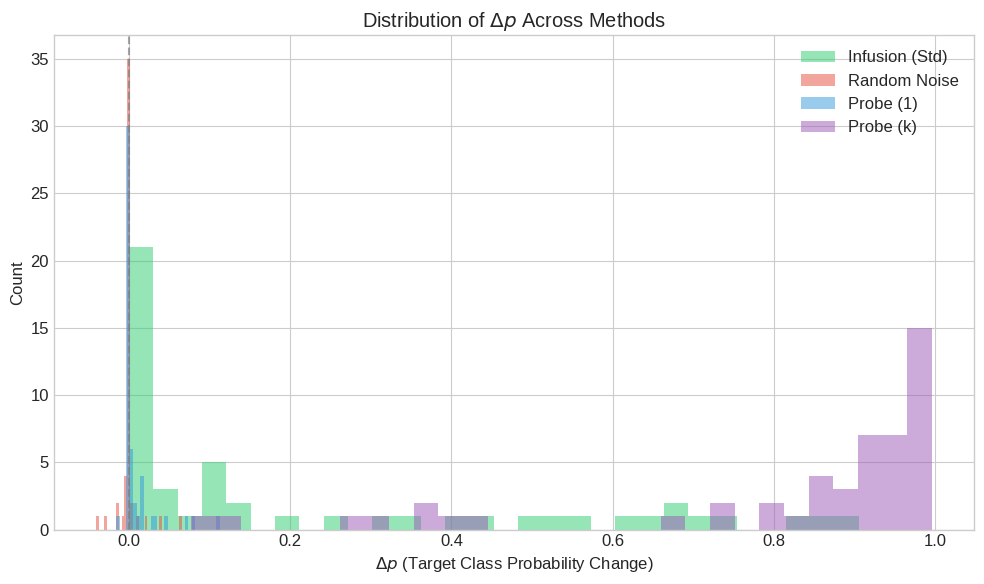

In [22]:
def plot_distributions(experiments: Dict[str, pd.DataFrame]):
    """Plot overlapping histograms of delta_prob distributions."""
    if not experiments:
        return
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    order = ['infusion', 'random_noise', 'probe_insert_single', 'probe_insert_all']
    
    for name in order:
        if name in experiments and 'delta_prob' in experiments[name].columns:
            data = experiments[name]['delta_prob']
            ax.hist(data, bins=30, alpha=0.5, label=DISPLAY_NAMES[name], color=COLORS[name])
    
    ax.axvline(x=0, color='gray', linestyle='--', alpha=0.7)
    ax.set_xlabel('$\\Delta p$ (Target Class Probability Change)')
    ax.set_ylabel('Count')
    ax.set_title('Distribution of $\\Delta p$ Across Methods')
    ax.legend()
    
    plt.tight_layout()
    plt.savefig(RESULTS_BASE / 'baselines_distributions.png', dpi=150, bbox_inches='tight')
    plt.show()


plot_distributions(experiments)

## Paired Scatter Plots

Compare methods on the same probe points (x = baseline, y = Infusion).


Random Noise vs Infusion (Std):
  Paired samples: 50
  test_image_idx match: ✓ All match
  true_label match: ✓ All match
  Correlation: r=0.085, p=5.59e-01

Probe (1) vs Infusion (Std):
  Paired samples: 50
  test_image_idx match: ✓ All match
  true_label match: ✓ All match
  Correlation: r=0.653, p=2.69e-07

Probe (k) vs Infusion (Std):
  Paired samples: 50
  test_image_idx match: ✓ All match
  true_label match: ✓ All match
  Correlation: r=0.257, p=7.13e-02


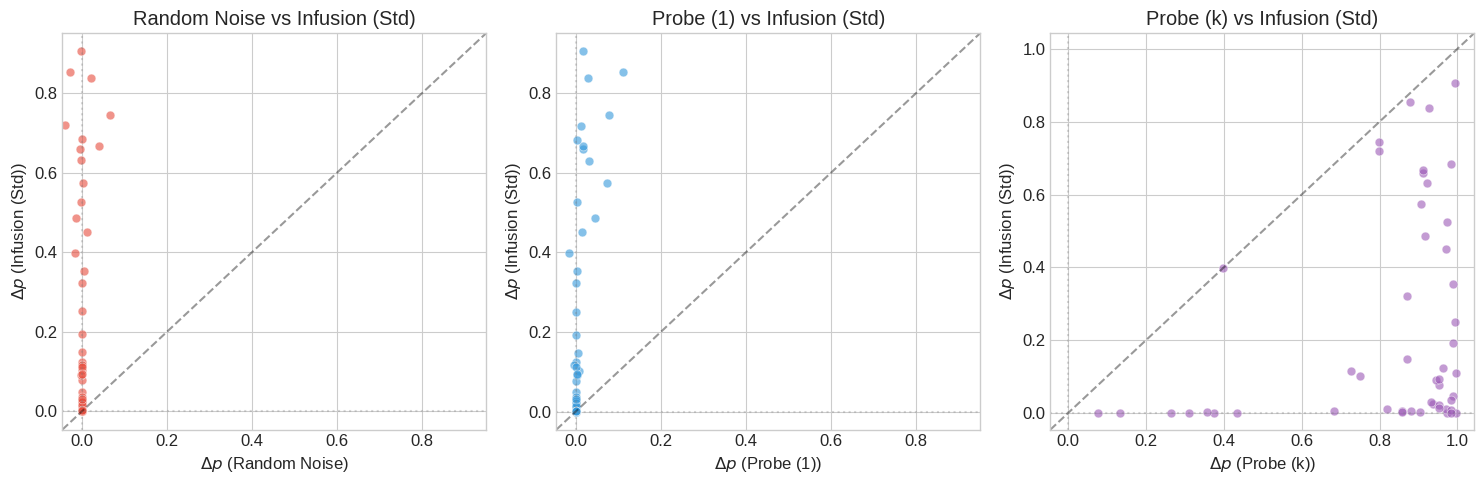

In [23]:
def plot_paired_scatter(experiments: Dict[str, pd.DataFrame], reference: str = 'infusion'):
    """Scatter plot comparing each baseline vs reference on same probe points."""
    if reference not in experiments:
        print(f"Reference '{reference}' not found.")
        return
    
    ref_df = experiments[reference]
    baselines = ['random_noise', 'probe_insert_single', 'probe_insert_all']
    available = [b for b in baselines if b in experiments]
    
    if not available:
        print("No baselines to compare.")
        return
    
    fig, axes = plt.subplots(1, len(available), figsize=(5*len(available), 5))
    if len(available) == 1:
        axes = [axes]
    
    for ax, baseline in zip(axes, available):
        df = experiments[baseline]
        
        # Merge on sample_idx and target_class
        merged = ref_df.merge(df, on=['sample_idx', 'target_class'], suffixes=('_ref', '_baseline'))
        
        if len(merged) < 2:
            ax.text(0.5, 0.5, 'Insufficient paired data', ha='center', va='center', transform=ax.transAxes)
            continue
        
        # Validate that true_label matches (same probe image)
        if 'true_label_ref' in merged.columns and 'true_label_baseline' in merged.columns:
            label_match = (merged['true_label_ref'] == merged['true_label_baseline']).all()
            n_mismatched = (merged['true_label_ref'] != merged['true_label_baseline']).sum()
        else:
            label_match = None
            n_mismatched = 0
        
        # Validate test_image_idx matches (same exact image)
        if 'test_image_idx_ref' in merged.columns and 'test_image_idx_baseline' in merged.columns:
            idx_match = (merged['test_image_idx_ref'] == merged['test_image_idx_baseline']).all()
            n_idx_mismatched = (merged['test_image_idx_ref'] != merged['test_image_idx_baseline']).sum()
        else:
            idx_match = None
            n_idx_mismatched = 0
        
        x = merged['delta_prob_baseline']
        y = merged['delta_prob_ref']
        
        ax.scatter(x, y, alpha=0.6, s=40, color=COLORS[baseline], edgecolor='white', linewidth=0.5)
        
        # Diagonal line (y=x)
        lims = [min(ax.get_xlim()[0], ax.get_ylim()[0], 0), 
                max(ax.get_xlim()[1], ax.get_ylim()[1])]
        ax.plot(lims, lims, 'k--', alpha=0.4, label='y=x')
        ax.set_xlim(lims)
        ax.set_ylim(lims)
        
        # Reference lines at 0
        ax.axhline(y=0, color='gray', linestyle=':', alpha=0.3)
        ax.axvline(x=0, color='gray', linestyle=':', alpha=0.3)
        
        ax.set_xlabel(f'$\\Delta p$ ({DISPLAY_NAMES[baseline]})')
        ax.set_ylabel(f'$\\Delta p$ ({DISPLAY_NAMES[reference]})')
        ax.set_title(f'{DISPLAY_NAMES[baseline]} vs {DISPLAY_NAMES[reference]}')
        
        # Correlation
        r, p = stats.pearsonr(x, y)
        
        # Simple annotation with just n and r
        # ax.annotate(f'n={len(merged)}, r={r:.2f}', 
        #            xy=(0.05, 0.95), xycoords='axes fraction', ha='left', va='top',
        #            fontsize=9, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        # Print detailed validation to console
        print(f"\n{DISPLAY_NAMES[baseline]} vs {DISPLAY_NAMES[reference]}:")
        print(f"  Paired samples: {len(merged)}")
        if idx_match is not None:
            print(f"  test_image_idx match: {'✓ All match' if idx_match else f'✗ {n_idx_mismatched} mismatches'}")
        if label_match is not None:
            print(f"  true_label match: {'✓ All match' if label_match else f'✗ {n_mismatched} mismatches'}")
        print(f"  Correlation: r={r:.3f}, p={p:.2e}")
    
    plt.tight_layout()
    plt.savefig('figures/baselines_paired_scatter.png', dpi=150, bbox_inches='tight')
    plt.show()


plot_paired_scatter(experiments)